In [1]:
import os

import pandas as pd
import scanpy as sc

import DeconV as dv

In [2]:
wrkdir = os.path.join(os.path.expanduser("~"), "Documents", "dev", "fimm", "data", "xin")
reference_file = os.path.join(wrkdir, "sc.tsv")
reference_mdata_file = os.path.join(wrkdir, "pdata.tsv")
bulk_file = os.path.join(wrkdir, "bulk.tsv")

cell_types = ["alpha", "delta", "gamma", "beta"]

In [3]:
sadata = dv.tl.read_data(reference_file)

pheno_df = pd.read_csv(reference_mdata_file, sep="\t", index_col=0)
pheno_df.index.name = None
common_cells = list(set(pheno_df.index.tolist()) & set(sadata.obs_names.tolist()))

sadata = sadata[common_cells, :].copy()
pheno_df = pheno_df.loc[common_cells, :].copy()
sadata.obs["labels"] = pheno_df["cellType"].tolist()
sadata.obs["labels"] = sadata.obs["labels"].astype("category")

sadata = sadata[sadata.obs["labels"].astype("str").isin(cell_types), :].copy()

bulk_df = pd.read_csv(bulk_file, sep="\t", index_col=None)
if bulk_df.iloc[:,0].dtype == "O":
    bulk_df.set_index(bulk_df.columns[0], inplace=True)

sc.pp.filter_cells(sadata, min_genes=200)
sc.pp.filter_genes(sadata, min_counts=100)

adata = dv.tl.combine(sadata, bulk_df)
del sadata

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=None)
adata.layers["ncounts"] = adata.X.copy()
sc.pp.log1p(adata)

adata.obs.groupby("labels").size()

scRNA-seq data - cells: 748, genes: 15029
bulk RNA-seq data - samples: 18, genes: 15029


labels
alpha    443
beta     171
delta     59
gamma     75
dtype: int64

In [4]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


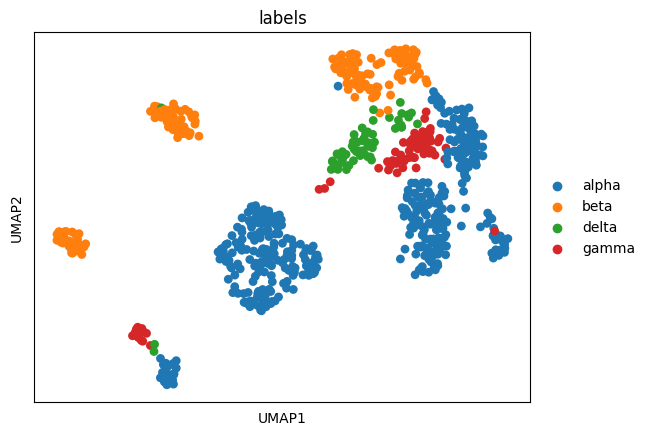

In [5]:
sc.tl.leiden(adata, resolution=0.1)
# adata.obs["cell_type"] = adata.obs["leiden"].astype("category").cat.rename_categories(["MDA-MB-438", "MCF7", "HF"])
adata.obs.drop(columns=["leiden"], inplace=True)
sc.pl.umap(adata, color=["labels"])

In [8]:
# Scaden
# bulk
bulk_df.T.to_csv(os.path.join("data", "xin_bulk_data.csv"))
# count matrix
pd.DataFrame(adata.layers["counts"], index=adata.obs_names, columns=adata.var_names).to_csv(os.path.join("data", "xin_counts.csv"))
# cell types
adata.obs["sampleID"] = 0
adata.obs["sampleID"].iloc[0] = 1
adata.obs[["labels", "sampleID"]].to_csv(os.path.join("data", "xin_celltypes.csv"))